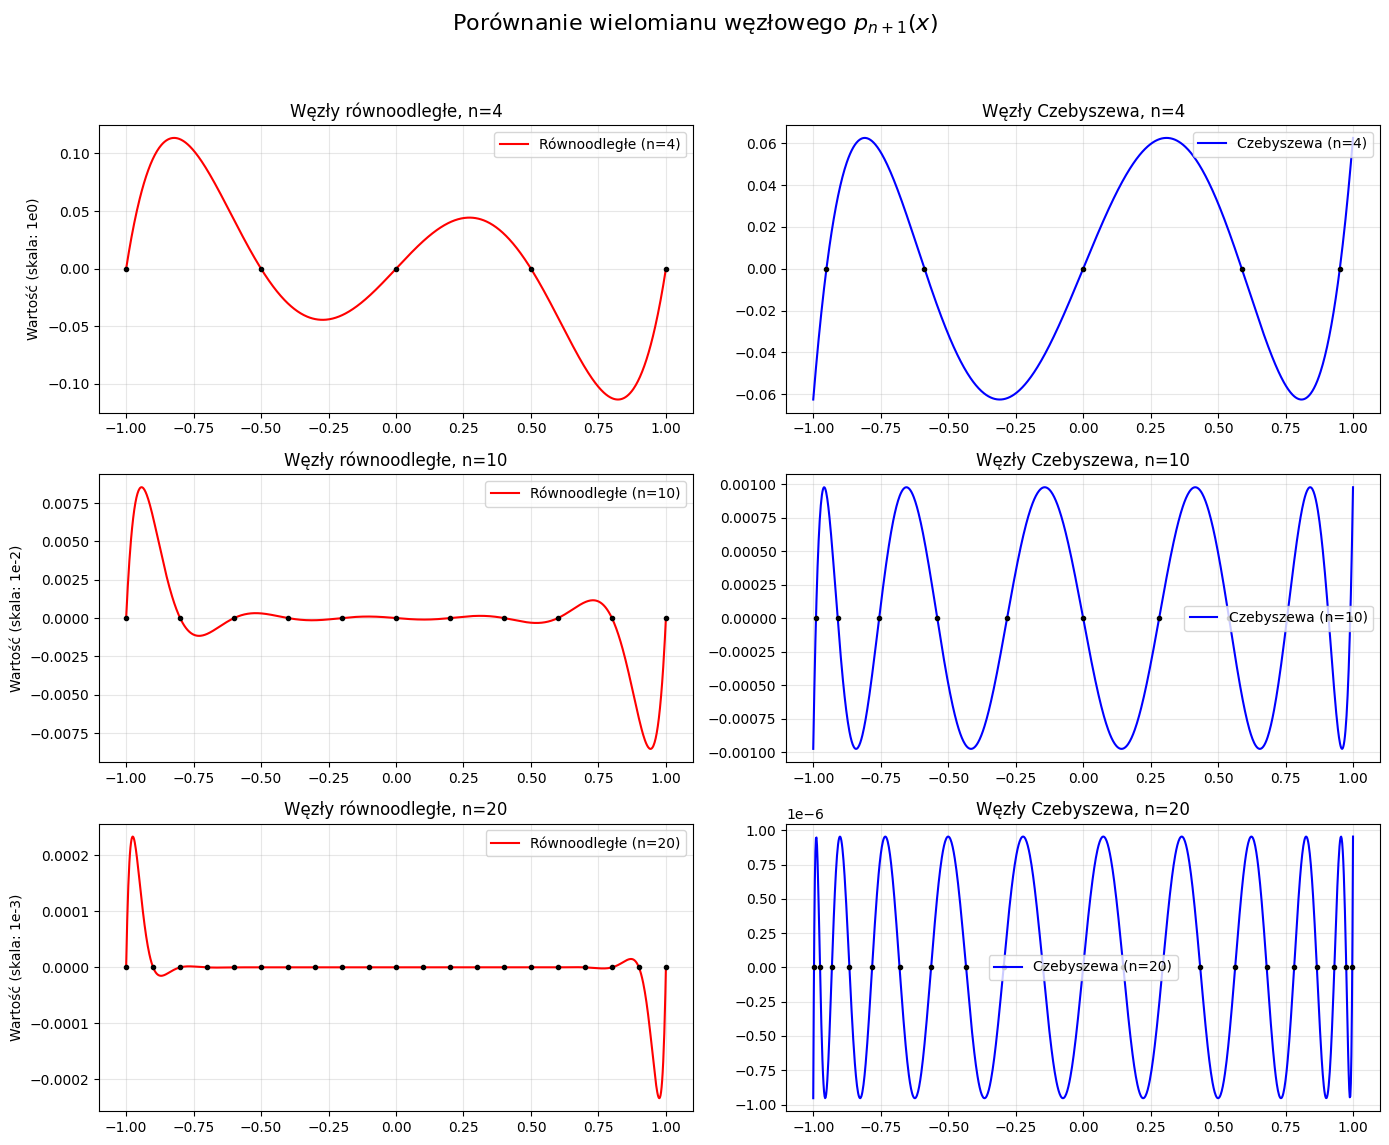

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def chebyshev_nodes(n):
    k = np.arange(n + 1)
    nodes = np.cos((2 * k + 1) * np.pi / (2 * n + 2))
    return nodes


def equidistant_nodes(n):
    return np.linspace(-1, 1, n + 1)


def nodal_polynomial(x_grid, nodes):
    vals = []
    for x in x_grid:
        val = np.prod(x - nodes)
        vals.append(val)
    return np.array(vals)


n_values = [4, 10, 20]
x_plot = np.linspace(-1, 1, 1000)


fig, axes = plt.subplots(len(n_values), 2, figsize=(14, 12))
fig.suptitle('Porównanie wielomianu węzłowego $p_{n+1}(x)$', fontsize=16)

for i, n in enumerate(n_values):
    nodes_eq = equidistant_nodes(n)
    nodes_ch = chebyshev_nodes(n)
    y_eq = nodal_polynomial(x_plot, nodes_eq)
    y_ch = nodal_polynomial(x_plot, nodes_ch)


    ax_eq = axes[i, 0]
    ax_eq.plot(x_plot, y_eq, 'r-', label=f'Równoodległe (n={n})')
    ax_eq.plot(nodes_eq, np.zeros_like(nodes_eq), 'ko', markersize=3)
    ax_eq.set_title(f'Węzły równoodległe, n={n}')
    ax_eq.set_ylabel(f'Wartość (skala: 1e{int(np.log10(np.max(np.abs(y_eq)) + 1e-16))})')
    ax_eq.grid(True, alpha=0.3)
    ax_eq.legend()


    ax_ch = axes[i, 1]
    ax_ch.plot(x_plot, y_ch, 'b-', label=f'Czebyszewa (n={n})')
    ax_ch.plot(nodes_ch, np.zeros_like(nodes_ch), 'ko', markersize=3)
    ax_ch.set_title(f'Węzły Czebyszewa, n={n}')
    ax_ch.grid(True, alpha=0.3)
    ax_ch.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()